In [23]:
import numpy as np
# Set numpy to print only 2 decimal digits for neatness
np.set_printoptions(precision=2, suppress=True)

import pandas as pd
import nibabel as nib
# from nibabel.testing import data_path
# import nilearn as nil
from nilearn import plotting
# from nilearn import image
import scipy.ndimage as ndi
import matplotlib.pyplot as plt

In [46]:
mri_df = pd.read_csv("../data/mri_10_08_2026.csv")
print(mri_df["Acq Date"].unique())
mri_df.head(1)
# file locations have syntax of 
# f"../data/scans/MRI/{mri_df["Subject"]}/{mri_df["Description"]}/2000-01-01_00_00_00.0/{mri_df["Image Data ID"]}/"

<StringArray>
['1/01/2000']
Length: 1, dtype: str


,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,I328631,50002,Autism,M,17,BL,MRI,MP-RAGE,Original,1/01/2000,NiFTI,Yes


In [48]:
file = "../data/MRI/50002/MP-RAGE/2000-01-01_00_00_00.0/I328631/ABIDE_50002_MRI_MP-RAGE_br_raw_20120830172854796_S164623_I328631.nii"
brain_vol = nib.load(file)
print(brain_vol.header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='>'
sizeof_hdr      : 348
data_type       : b''
db_name         : b'50002'
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 176 256 256   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.    1.05  1.05  1.05  0.    0.    0.    0.  ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'FSL4.1'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 94.78057098388672
qoffset_y       : -130.6598663330078
qoffset_z    

In [20]:
brain_vol_data = brain_vol.get_fdata()
brain_vol_data.shape

(176, 256, 256)

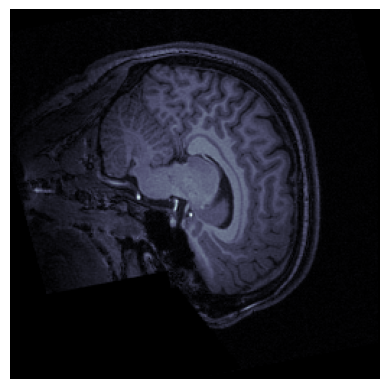

In [21]:
plt.imshow(brain_vol_data[96], cmap='bone')
plt.axis('off')
plt.show()

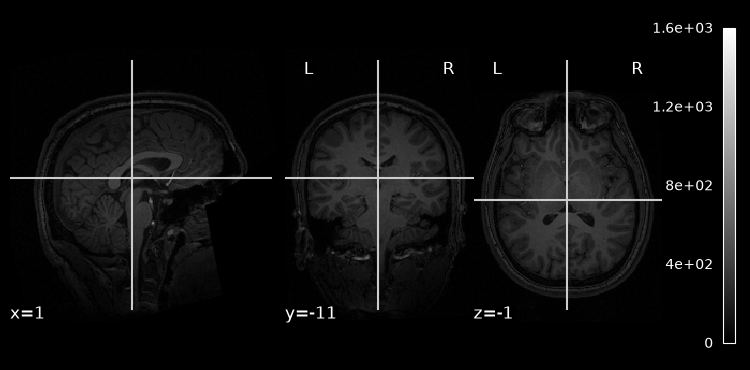

In [22]:
plotting.plot_anat(brain_vol)
plt.show()

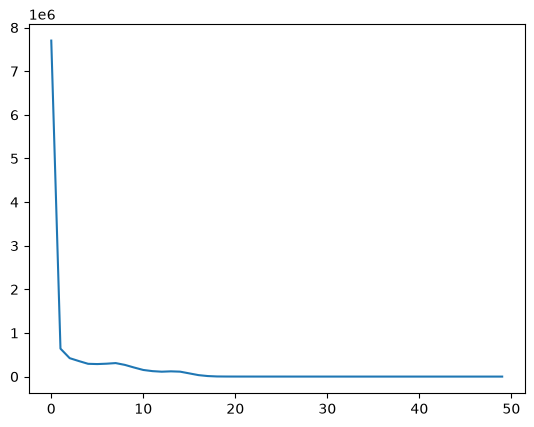

In [25]:
plt.plot(ndi.histogram(brain_vol_data, min=0, max=np.max(brain_vol_data), bins=50))
plt.show()

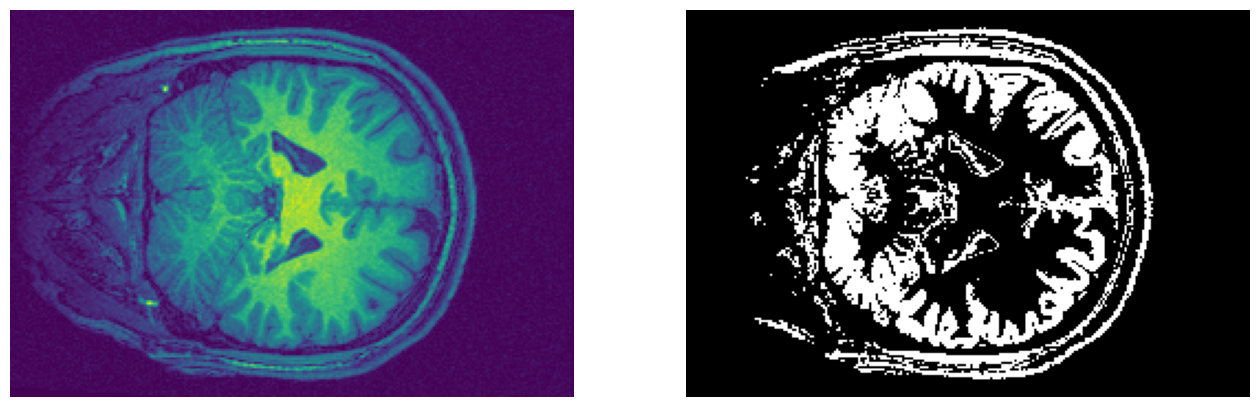

In [42]:
gm_min = ((np.max(brain_vol_data)) / 50) * 5
gm_max = ((np.max(brain_vol_data)) / 50) * 10

brain_mask1 = np.where(brain_vol_data > gm_min, 1, 0)
brain_mask2 = np.where(brain_vol_data < gm_max, 1, 0)

brain_mask = brain_mask1 + brain_mask2
brain_mask = np.where(brain_mask == 2, 1, 0)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(brain_vol_data[:, 96, :])
ax[0].axis('off')

ax[1].imshow(brain_mask[:, 96, :], cmap='gray')
ax[1].axis('off')
plt.show()

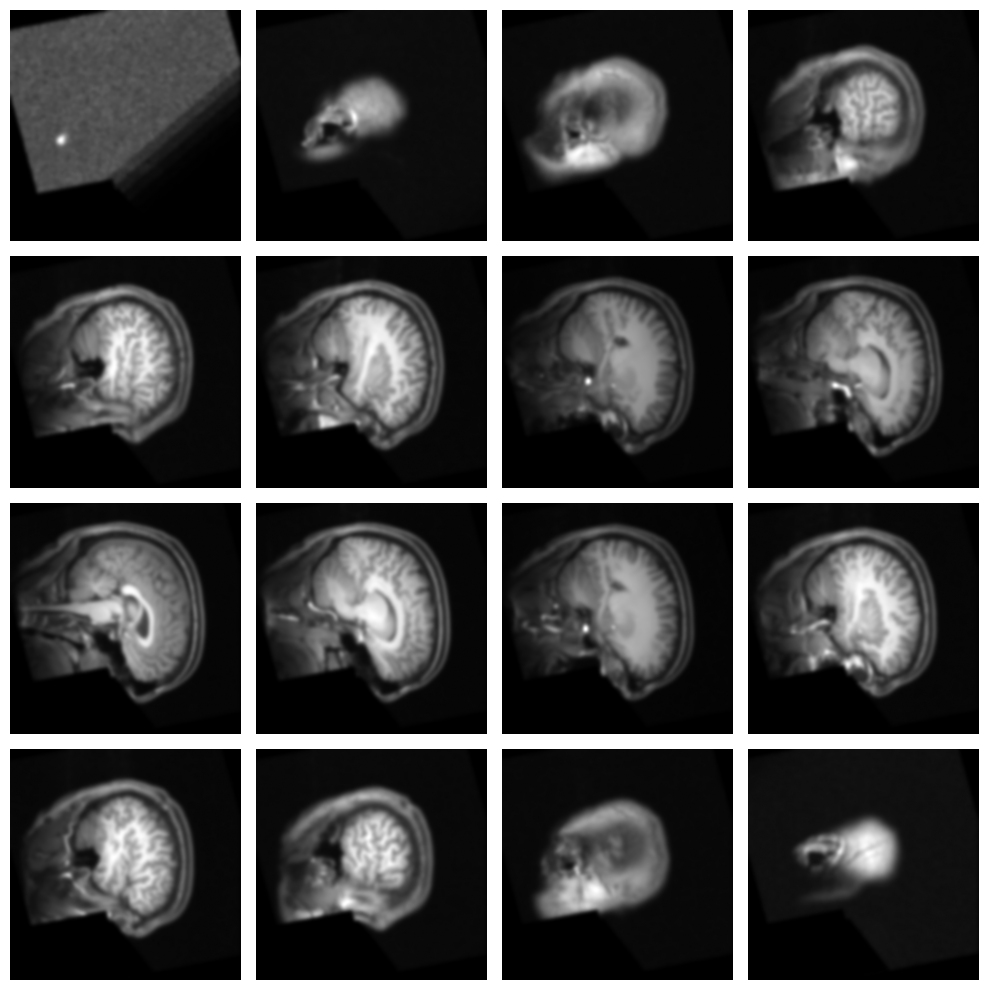

In [28]:
sigma = 2
smoothed = ndi.gaussian_filter(brain_vol_data, sigma)

fig_rows = 4
fig_cols = 4
n_subplots = fig_rows * fig_cols
n_slice = brain_vol_data.shape[0]
step_size = n_slice // n_subplots
plot_range = n_subplots * step_size

start_stop = int((n_slice - plot_range) / 2)


fig, axs = plt.subplots(fig_rows, fig_cols, figsize=[10, 10])

for idx, img in enumerate(range(start_stop, plot_range, step_size)):
    axs.flat[idx].imshow(smoothed[img, :, :], cmap='gray')
    axs.flat[idx].axis('off')
        
plt.tight_layout()
plt.show()

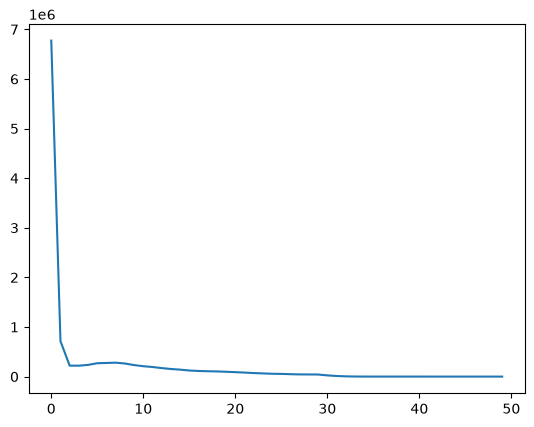

In [29]:
filt = ndi.gaussian_filter(brain_vol_data, sigma=2)
plt.plot(ndi.histogram(filt, min=0, max=np.max(filt), bins=50))
plt.show()

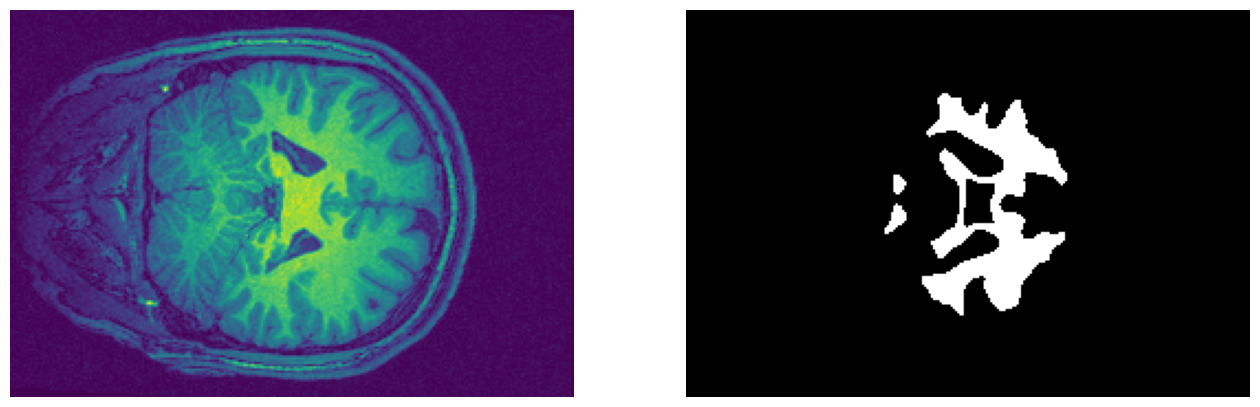

In [50]:
gm_min = ((np.max(filt)) / 50) * 25
gm_max = ((np.max(filt)) / 50) * 32

brain_mask1 = np.where(filt > gm_min, 1, 0)
brain_mask2 = np.where(filt < gm_max, 1, 0)

brain_mask = brain_mask1 + brain_mask2
brain_mask = np.where(brain_mask == 2, 1, 0)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(brain_vol_data[:, 96, :])
ax[0].axis('off')

ax[1].imshow(brain_mask[:, 96, :], cmap='gray')
ax[1].axis('off')
plt.show()